# Feature Engineering


## Setup


In [1]:
import json
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)

APPLICATION_PATH = Path("../data/application_train_clean.parquet")
BUREAU_PATH = Path("../data/bureau.csv")
SPLIT_PATH = Path("../data/split_assignments.parquet")

application = pd.read_parquet(APPLICATION_PATH)
bureau = pd.read_csv(BUREAU_PATH)
split_assignments = pd.read_parquet(SPLIT_PATH)[["SK_ID_CURR", "SPLIT"]]

features = application.copy()

print(f"Application data: {application.shape}")
print(f"Bureau data: {bureau.shape}")

Application data: (307511, 166)
Bureau data: (1716428, 17)


## Application Features

Ratios normalize requested credit and repayment burden by applicant resources, while age and employment features convert day offsets into interpretable units. External-score aggregates reduce missingness across three related sources, and document/contact counts summarize sparse indicator families without using TARGET.

In [2]:
def safe_divide(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    result = numerator / denominator
    return result.replace([np.inf, -np.inf], np.nan)

In [3]:
def engineer_application_features(frame):
    out = frame.copy()

    out["AGE_YEARS"] = -out["DAYS_BIRTH"] / 365.25
    out["EMPLOYMENT_YEARS"] = -out["DAYS_EMPLOYED"] / 365.25

    out["CREDIT_INCOME_RATIO"] = safe_divide(out["AMT_CREDIT"], out["AMT_INCOME_TOTAL"])
    out["ANNUITY_INCOME_RATIO"] = safe_divide(out["AMT_ANNUITY"], out["AMT_INCOME_TOTAL"])
    out["CREDIT_TERM_PROXY"] = safe_divide(out["AMT_ANNUITY"], out["AMT_CREDIT"])
    out["EMPLOYMENT_AGE_RATIO"] = safe_divide(out["EMPLOYMENT_YEARS"], out["AGE_YEARS"])
    out["INCOME_PER_PERSON"] = safe_divide(out["AMT_INCOME_TOTAL"], out["CNT_FAM_MEMBERS"])
    out["CREDIT_GOODS_RATIO"] = safe_divide(out["AMT_CREDIT"], out["AMT_GOODS_PRICE"])
    out["ANNUITY_CREDIT_RATIO"] = safe_divide(out["AMT_ANNUITY"], out["AMT_CREDIT"])

    ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
    out["EXT_SOURCE_MEAN"] = out[ext_cols].mean(axis=1)
    out["EXT_SOURCE_STD"] = out[ext_cols].std(axis=1)
    out["EXT_SOURCE_MIN"] = out[ext_cols].min(axis=1)
    out["EXT_SOURCE_MAX"] = out[ext_cols].max(axis=1)
    out["EXT_SOURCE_MISSING_COUNT"] = out[ext_cols].isna().sum(axis=1).astype("int8")

    out["AGE_BUCKET"] = pd.cut(
        out["AGE_YEARS"],
        bins=[20, 30, 40, 50, 60, 70, 100],
        labels=["20-29", "30-39", "40-49", "50-59", "60-69", "70+"],
        include_lowest=True,
    )

    document_cols = [c for c in out.columns if c.startswith("FLAG_DOCUMENT_")]
    contact_cols = ["FLAG_MOBIL", "FLAG_WORK_PHONE", "FLAG_CONT_MOBILE", "FLAG_PHONE", "FLAG_EMAIL"]
    out["DOCUMENT_COUNT"] = out[document_cols].sum(axis=1)
    out["CONTACTABILITY_SCORE"] = out[contact_cols].sum(axis=1)

    return out


features = engineer_application_features(features)

engineered_application_cols = [
    "AGE_YEARS",
    "EMPLOYMENT_YEARS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_TERM_PROXY",
    "EMPLOYMENT_AGE_RATIO",
    "INCOME_PER_PERSON",
    "CREDIT_GOODS_RATIO",
    "ANNUITY_CREDIT_RATIO",
    "EXT_SOURCE_MEAN",
    "EXT_SOURCE_STD",
    "EXT_SOURCE_MIN",
    "EXT_SOURCE_MAX",
    "EXT_SOURCE_MISSING_COUNT",
    "AGE_BUCKET",
    "DOCUMENT_COUNT",
    "CONTACTABILITY_SCORE",
]

display(features[engineered_application_cols].describe(include="all"))

,AGE_YEARS,EMPLOYMENT_YEARS,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_TERM_PROXY,EMPLOYMENT_AGE_RATIO,INCOME_PER_PERSON,CREDIT_GOODS_RATIO,ANNUITY_CREDIT_RATIO,EXT_SOURCE_MEAN,EXT_SOURCE_STD,EXT_SOURCE_MIN,EXT_SOURCE_MAX,EXT_SOURCE_MISSING_COUNT,AGE_BUCKET,DOCUMENT_COUNT,CONTACTABILITY_SCORE
count,307511.000000,252137.000000,307511.000000,307499.000000,307499.000000,252137.000000,3.075090e+05,307233.000000,307499.000000,307339.000000,2.706020e+05,3.073390e+05,307339.000000,307511.000000,307511,307511.000000,307511.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30-39,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,82349,NaN,NaN
mean,43.906900,6.527500,3.957570,0.180930,0.053695,0.156861,9.310588e+04,1.122995,0.053695,0.509251,1.512456e-01,3.995821e-01,0.615882,0.764210,NaN,0.930155,2.535285
std,11.947950,6.402081,2.689728,0.094574,0.022481,0.133549,1.013734e+05,0.124045,0.022481,0.149802,9.991074e-02,1.874246e-01,0.156130,0.649986,NaN,0.344295,0.723976
min,20.503765,-0.000000,0.004808,0.000224,0.022073,-0.000000,2.812500e+03,0.150000,0.022073,0.000006,3.538459e-07,8.173617e-08,0.000006,0.000000,NaN,0.000000,1.000000
25%,33.984942,2.099932,2.018667,0.114782,0.036900,0.056099,4.725000e+04,1.000000,0.036900,0.413648,7.238552e-02,2.539628e-01,0.540654,0.000000,NaN,1.000000,2.000000
50%,43.121150,4.511978,3.265067,0.162833,0.050000,0.118733,7.500000e+04,1.118800,0.050000,0.524502,1.360209e-01,4.031671e-01,0.648470,1.000000,NaN,1.000000,2.000000
75%,53.886379,8.692676,5.159880,0.229067,0.064043,0.219170,1.125000e+05,1.198000,0.064043,0.622819,2.143878e-01,5.530128e-01,0.725276,1.000000,NaN,1.000000,3.000000


After engineering above features, some of the original features have become redundant. We will drop them to reduce multicolinearity.

In [4]:
features = features.drop(
    columns=["DAYS_BIRTH", "DAYS_EMPLOYED"], #made redundant by AGE_YEARS and EMPLOYMENT_YEARS
    errors="ignore",
)

## Bureau Aggregation

Bureau records are aggregated to one row per applicant using only information available at application time. Counts measure credit-history depth, status ratios describe portfolio composition, and overdue or debt amounts capture repayment stress without leaking TARGET.

In [5]:
def aggregate_bureau(bureau_frame):
    bureau_work = bureau_frame.copy()
    bureau_work["BUREAU_IS_ACTIVE"] = bureau_work["CREDIT_ACTIVE"].eq("Active").astype("int8")
    bureau_work["BUREAU_IS_CLOSED"] = bureau_work["CREDIT_ACTIVE"].eq("Closed").astype("int8")
    bureau_work["BUREAU_HAS_OVERDUE"] = bureau_work["AMT_CREDIT_SUM_OVERDUE"].fillna(0).gt(0).astype("int8")

    aggregated = bureau_work.groupby("SK_ID_CURR").agg(
        BUREAU_RECORD_COUNT=("SK_ID_BUREAU", "count"),
        BUREAU_ACTIVE_COUNT=("BUREAU_IS_ACTIVE", "sum"),
        BUREAU_CLOSED_COUNT=("BUREAU_IS_CLOSED", "sum"),
        BUREAU_OVERDUE_RECORD_COUNT=("BUREAU_HAS_OVERDUE", "sum"),
        BUREAU_DAYS_CREDIT_MEAN=("DAYS_CREDIT", "mean"),
        BUREAU_DAYS_CREDIT_MIN=("DAYS_CREDIT", "min"),
        BUREAU_CREDIT_SUM_MEAN=("AMT_CREDIT_SUM", "mean"),
        BUREAU_CREDIT_SUM_TOTAL=("AMT_CREDIT_SUM", "sum"),
        BUREAU_DEBT_TOTAL=("AMT_CREDIT_SUM_DEBT", "sum"),
        BUREAU_OVERDUE_MAX=("AMT_CREDIT_SUM_OVERDUE", "max"),
        BUREAU_DAYS_OVERDUE_MAX=("CREDIT_DAY_OVERDUE", "max"),
        BUREAU_PROLONG_COUNT=("CNT_CREDIT_PROLONG", "sum"),
    )

    aggregated["BUREAU_ACTIVE_RATIO"] = safe_divide(aggregated["BUREAU_ACTIVE_COUNT"], aggregated["BUREAU_RECORD_COUNT"])
    aggregated["BUREAU_DEBT_CREDIT_RATIO"] = safe_divide(aggregated["BUREAU_DEBT_TOTAL"], aggregated["BUREAU_CREDIT_SUM_TOTAL"])
    return aggregated.reset_index()


bureau_features = aggregate_bureau(bureau)

assert bureau_features["SK_ID_CURR"].is_unique
print(f"Bureau rows before aggregation: {len(bureau):,}")
print(f"Applicants represented after aggregation: {len(bureau_features):,}")
display(bureau_features.head())

Bureau rows before aggregation: 1,716,428
Applicants represented after aggregation: 305,811


,SK_ID_CURR,BUREAU_RECORD_COUNT,BUREAU_ACTIVE_COUNT,BUREAU_CLOSED_COUNT,BUREAU_OVERDUE_RECORD_COUNT,BUREAU_DAYS_CREDIT_MEAN,BUREAU_DAYS_CREDIT_MIN,BUREAU_CREDIT_SUM_MEAN,BUREAU_CREDIT_SUM_TOTAL,BUREAU_DEBT_TOTAL,BUREAU_OVERDUE_MAX,BUREAU_DAYS_OVERDUE_MAX,BUREAU_PROLONG_COUNT,BUREAU_ACTIVE_RATIO,BUREAU_DEBT_CREDIT_RATIO
0,100001,7,3,4,0,-735.000000,-1572,207623.571429,1453365.000,596686.5,0.0,0,0,0.428571,0.410555
1,100002,8,2,6,0,-874.000000,-1437,108131.945625,865055.565,245781.0,0.0,0,0,0.250000,0.284122
2,100003,4,1,3,0,-1400.750000,-2586,254350.125000,1017400.500,0.0,0.0,0,0,0.250000,0.000000
3,100004,2,0,2,0,-867.000000,-1326,94518.900000,189037.800,0.0,0.0,0,0,0.000000,0.000000
4,100005,3,2,1,0,-190.666667,-373,219042.000000,657126.000,568408.5,0.0,0,0,0.666667,0.864992


In [6]:
rows_before = len(features)
features = features.merge(
    bureau_features,
    on="SK_ID_CURR",
    how="left",
    validate="one_to_one",
)

bureau_engineered_cols = [c for c in bureau_features.columns if c != "SK_ID_CURR"]
features["BUREAU_HISTORY_MISSING"] = features["BUREAU_RECORD_COUNT"].isna().astype("int8")

count_cols = [
    "BUREAU_RECORD_COUNT",
    "BUREAU_ACTIVE_COUNT",
    "BUREAU_CLOSED_COUNT",
    "BUREAU_OVERDUE_RECORD_COUNT",
    "BUREAU_PROLONG_COUNT",
]
features[count_cols] = features[count_cols].fillna(0)

print(f"Merged feature-table shape: {features.shape}")
print(f"Applicants without bureau history: {features['BUREAU_HISTORY_MISSING'].sum():,}")

Merged feature-table shape: (307511, 196)
Applicants without bureau history: 44,020


## Feature Validation

Validation checks enforce finite ratios, plausible ages, non-negative income-per-person values, and unique application identifiers. ANNUITY_CREDIT_RATIO is removed because it duplicates CREDIT_TERM_PROXY exactly.

In [7]:
numeric_engineered = features[engineered_application_cols + bureau_engineered_cols].select_dtypes(include=np.number)

quality_report = pd.Series({
    "infinite_values": np.isinf(numeric_engineered.to_numpy()).sum(),
    "age_below_20": features["AGE_YEARS"].lt(20).sum(),
    "age_above_100": features["AGE_YEARS"].gt(100).sum(),
    "negative_income_per_person": features["INCOME_PER_PERSON"].lt(0).sum(),
    "duplicate_application_ids": features["SK_ID_CURR"].duplicated().sum(),
})
display(quality_report.to_frame("value"))

features = features.drop(columns="ANNUITY_CREDIT_RATIO")
engineered_application_cols.remove("ANNUITY_CREDIT_RATIO")

,value
infinite_values,0
age_below_20,0
age_above_100,0
negative_income_per_person,0
duplicate_application_ids,0


## Multicollinearity

Highly correlated engineered fields are retained for tree models but flagged for review because they can destabilize linear coefficients and produce redundant explanations. Exact duplicates are removed, while related external-score summaries remain available for validation and SHAP comparison.

In [8]:
review_cols = features[engineered_application_cols + bureau_engineered_cols].select_dtypes(include=np.number).columns
corr = features[review_cols].corr()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr_pairs = (
    upper.stack()
    .rename("correlation")
    .loc[lambda s: s.abs() > 0.95]
    .sort_values(key=np.abs, ascending=False)
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)

display(high_corr_pairs)

,feature_1,feature_2,correlation
0,EMPLOYMENT_YEARS,EMPLOYMENT_AGE_RATIO,0.954679


## Target Relationships

Target correlations are diagnostic only and are never used to construct features. They help verify that engineered variables contain plausible signal before the fixed train/holdout split is used for model selection.

,correlation_with_TARGET
EXT_SOURCE_MEAN,-0.222052
EXT_SOURCE_MAX,-0.196876
EXT_SOURCE_MIN,-0.185266
BUREAU_DAYS_CREDIT_MEAN,0.089729
AGE_YEARS,-0.078239
BUREAU_ACTIVE_RATIO,0.077356
BUREAU_DAYS_CREDIT_MIN,0.075248
EMPLOYMENT_YEARS,-0.074958
CREDIT_GOODS_RATIO,0.069427
EMPLOYMENT_AGE_RATIO,-0.067955


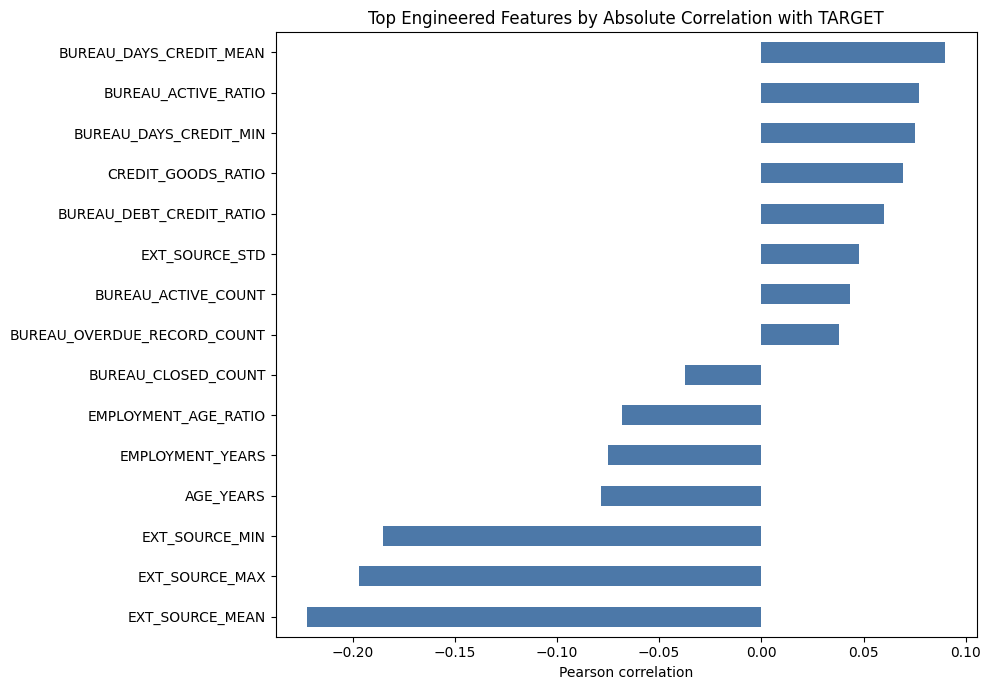

In [9]:
engineered_numeric_cols = features[engineered_application_cols + bureau_engineered_cols].select_dtypes(include=np.number).columns
engineered_target_corr = (
    features[list(engineered_numeric_cols) + ["TARGET"]]
    .corr()["TARGET"]
    .drop("TARGET")
    .sort_values(key=np.abs, ascending=False)
)

display(engineered_target_corr.head(20).to_frame("correlation_with_TARGET"))

plt.figure(figsize=(10, 7))
engineered_target_corr.head(15).sort_values().plot(kind="barh", color="#4C78A8")
plt.title("Top Engineered Features by Absolute Correlation with TARGET")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()

## Categorical Encoding

NAME_EDUCATION_TYPE receives an ordinal representation because its levels have a defensible ordering. Other categories at or below 50 levels are one-hot encoded in the model pipeline, while higher-cardinality fields are excluded to avoid unstable sparse levels; CODE_GENDER and NAME_FAMILY_STATUS are retained only for governance analysis and excluded from decisioning.

In [10]:
education_order = {
    "Lower secondary": 0,
    "Secondary / secondary special": 1,
    "Incomplete higher": 2,
    "Higher education": 3,
    "Academic degree": 4,
}
features["EDUCATION_ORDINAL"] = features["NAME_EDUCATION_TYPE"].map(education_order)

categorical_cols = features.select_dtypes(exclude=np.number).columns.tolist()
cardinality = features[categorical_cols].nunique(dropna=False).sort_values(ascending=False)
high_cardinality_cols = cardinality[cardinality > 50].index.tolist()
low_cardinality_cols = cardinality[cardinality <= 50].index.tolist()

encoding_plan = pd.DataFrame({
    "cardinality": cardinality,
    "strategy": [
        "Drop from training pipeline" if col in high_cardinality_cols
        else "One-hot encoding inside training pipeline"
        for col in cardinality.index
    ],
})
encoding_plan.loc["NAME_EDUCATION_TYPE", "strategy"] = "Ordinal mapping; exclude original category"
governance_excluded_features = ["CODE_GENDER", "NAME_FAMILY_STATUS"]
model_drop_features = sorted(set(high_cardinality_cols + ["NAME_EDUCATION_TYPE"] + governance_excluded_features))

display(encoding_plan)

,cardinality,strategy
ORGANIZATION_TYPE,58,Drop from training pipeline
OCCUPATION_TYPE,19,One-hot encoding inside training pipeline
WALLSMATERIAL_MODE,8,One-hot encoding inside training pipeline
NAME_TYPE_SUITE,8,One-hot encoding inside training pipeline
NAME_INCOME_TYPE,8,One-hot encoding inside training pipeline
WEEKDAY_APPR_PROCESS_START,7,One-hot encoding inside training pipeline
NAME_FAMILY_STATUS,6,One-hot encoding inside training pipeline
NAME_HOUSING_TYPE,6,One-hot encoding inside training pipeline
FONDKAPREMONT_MODE,5,One-hot encoding inside training pipeline
NAME_EDUCATION_TYPE,5,Ordinal mapping; exclude original category


## Customer Segmentation

Clustering uses seven scaled application-time measures and is fitted only on training rows. Median imputation, percentile clipping, scaling, k selection, and final centroids are all learned without holdout data; the resulting model then assigns segments to both populations.

,k,inertia,silhouette
0,2,285145.813266,0.175458
1,3,248830.784795,0.157050
2,4,222825.362831,0.154446
3,5,203395.484227,0.156188
4,6,185387.218787,0.168035
5,7,175673.053390,0.152245
6,8,167645.712587,0.143777


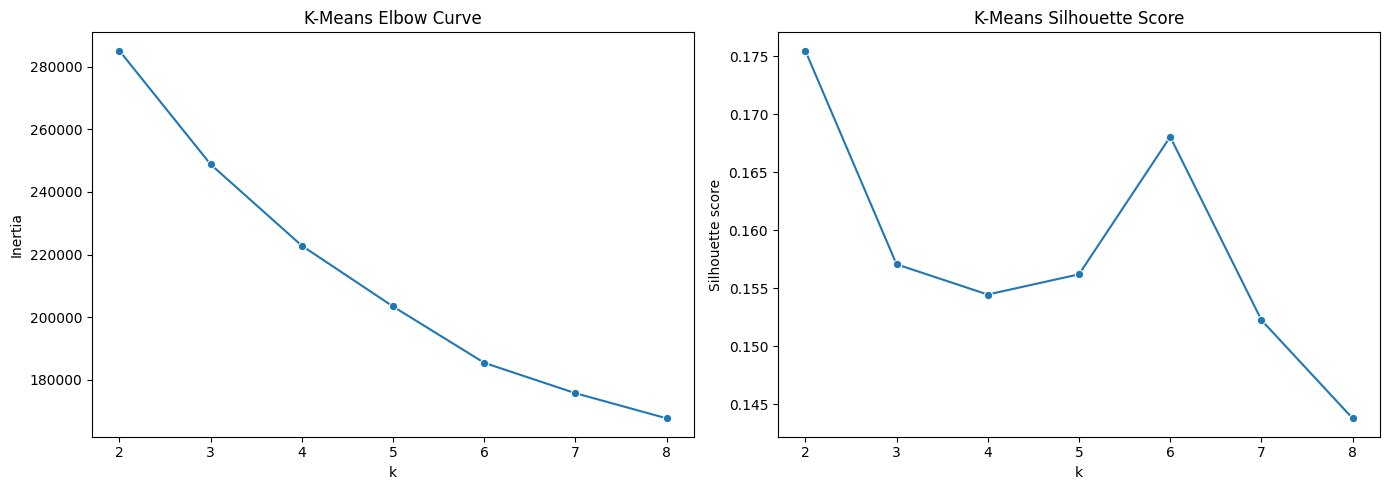

Selected k=2 from training data using the highest sampled silhouette score.


In [11]:
cluster_features = [
    "AGE_YEARS",
    "AMT_INCOME_TOTAL",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "EXT_SOURCE_MEAN",
    "BUREAU_RECORD_COUNT",
    "BUREAU_DEBT_CREDIT_RATIO",
]

cluster_frame = features[["SK_ID_CURR"] + cluster_features].merge(
    split_assignments,
    on="SK_ID_CURR",
    how="left",
    validate="one_to_one",
)
train_mask = cluster_frame["SPLIT"].eq("train").to_numpy()
cluster_medians = cluster_frame.loc[train_mask, cluster_features].median()
cluster_data = cluster_frame[cluster_features].fillna(cluster_medians)

clip_bounds = {}
for col in cluster_features:
    lower, upper = cluster_data.loc[train_mask, col].quantile([0.01, 0.99])
    clip_bounds[col] = (float(lower), float(upper))
    cluster_data[col] = cluster_data[col].clip(lower, upper)

scaler = StandardScaler()
scaler.fit(cluster_data.loc[train_mask, cluster_features])
cluster_scaled = scaler.transform(cluster_data[cluster_features])

rng = np.random.default_rng(42)
training_positions = np.flatnonzero(train_mask)
sample_size = min(50_000, len(training_positions))
sample_positions = rng.choice(training_positions, size=sample_size, replace=False)
cluster_sample = cluster_scaled[sample_positions]

scores = []
for k in range(2, 9):
    candidate = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = candidate.fit_predict(cluster_sample)
    scores.append({
        "k": k,
        "inertia": candidate.inertia_,
        "silhouette": silhouette_score(
            cluster_sample,
            labels,
            sample_size=min(10_000, sample_size),
            random_state=42,
        ),
    })

cluster_scores = pd.DataFrame(scores)
display(cluster_scores)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=cluster_scores, x="k", y="inertia", marker="o", ax=axes[0])
sns.lineplot(data=cluster_scores, x="k", y="silhouette", marker="o", ax=axes[1])
axes[0].set_title("K-Means Elbow Curve")
axes[0].set_ylabel("Inertia")
axes[1].set_title("K-Means Silhouette Score")
axes[1].set_ylabel("Silhouette score")
for ax in axes:
    ax.set_xticks(cluster_scores["k"])
plt.tight_layout()
plt.show()

best_k = int(cluster_scores.loc[cluster_scores["silhouette"].idxmax(), "k"])
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_kmeans.fit(cluster_scaled[train_mask])
features["CUSTOMER_SEGMENT"] = final_kmeans.predict(cluster_scaled)

segmentation_bundle = {
    "features": cluster_features,
    "medians": cluster_medians.to_dict(),
    "clip_bounds": clip_bounds,
    "scaler": scaler,
    "kmeans": final_kmeans,
}
print(f"Selected k={best_k} from training data using the highest sampled silhouette score.")

,applicants,default_rate,mean_age,mean_income,mean_credit_income,mean_annuity_income,mean_external_score,mean_bureau_records,mean_bureau_debt_credit,default_rate_pct,business_name
CUSTOMER_SEGMENT,,,,,,,,,,,
0,102378,0.074342,47.127978,122525.976264,6.633063,0.278456,0.533981,4.039256,0.219717,7.434214,Lower-risk moderate-income credit-stretched (S0)
1,205133,0.083916,42.299320,191891.370784,2.622282,0.132254,0.496908,5.127376,0.311870,8.391629,Higher-risk higher-income lower-leverage (S1)


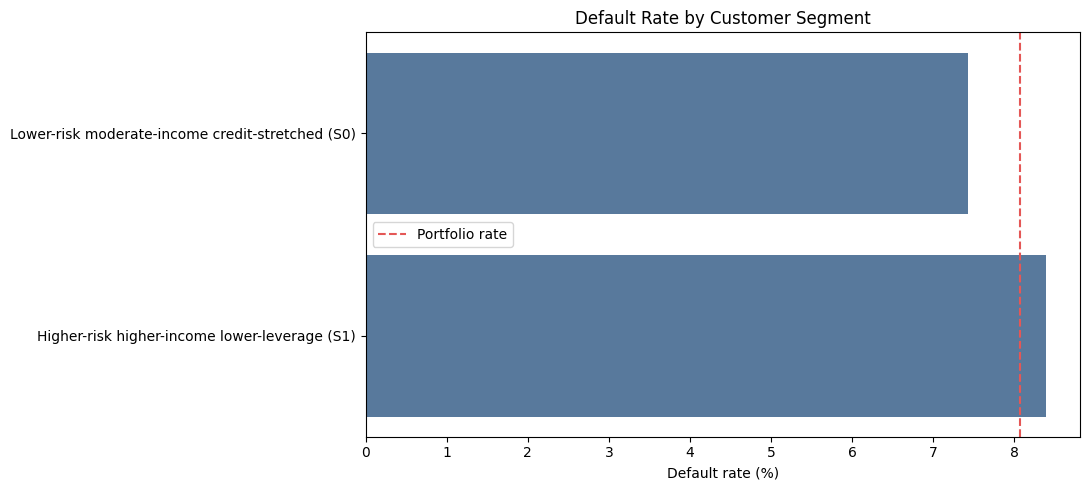

In [12]:
segment_profile = features.groupby("CUSTOMER_SEGMENT").agg(
    applicants=("SK_ID_CURR", "size"),
    default_rate=("TARGET", "mean"),
    mean_age=("AGE_YEARS", "mean"),
    mean_income=("AMT_INCOME_TOTAL", "mean"),
    mean_credit_income=("CREDIT_INCOME_RATIO", "mean"),
    mean_annuity_income=("ANNUITY_INCOME_RATIO", "mean"),
    mean_external_score=("EXT_SOURCE_MEAN", "mean"),
    mean_bureau_records=("BUREAU_RECORD_COUNT", "mean"),
    mean_bureau_debt_credit=("BUREAU_DEBT_CREDIT_RATIO", "mean"),
)
segment_profile["default_rate_pct"] = segment_profile["default_rate"] * 100

portfolio_default_rate = features["TARGET"].mean()
income_reference = segment_profile["mean_income"].median()
leverage_reference = segment_profile["mean_credit_income"].median()

def describe_segment(row):
    risk = "Higher-risk" if row["default_rate"] > portfolio_default_rate else "Lower-risk"
    income = "higher-income" if row["mean_income"] > income_reference else "moderate-income"
    leverage = "credit-stretched" if row["mean_credit_income"] > leverage_reference else "lower-leverage"
    return f"{risk} {income} {leverage} (S{int(row.name)})"

segment_profile["business_name"] = segment_profile.apply(describe_segment, axis=1)
segment_names = segment_profile["business_name"].to_dict()
features["CUSTOMER_SEGMENT_NAME"] = features["CUSTOMER_SEGMENT"].map(segment_names)
display(segment_profile)

plt.figure(figsize=(11, 5))
plot_profile = segment_profile.sort_values("default_rate_pct")
sns.barplot(data=plot_profile, x="default_rate_pct", y="business_name", color="#4C78A8")
plt.axvline(portfolio_default_rate * 100, color="#E45756", linestyle="--", label="Portfolio rate")
plt.title("Default Rate by Customer Segment")
plt.xlabel("Default rate (%)")
plt.ylabel("")
plt.legend()
plt.tight_layout()
plt.show()

## Save Features

The Parquet table is the efficient modeling artifact, while preprocessed_train.csv is written as a curriculum-compatible deliverable. The segmentation transformer and feature dictionary are saved so later notebooks can reproduce exclusions and assign clusters consistently.

In [13]:
OUTPUT_DIR = Path("../data")
MODEL_DIR = Path("../models")
REPORT_DIR = Path("../reports")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

feature_path = OUTPUT_DIR / "application_features.parquet"
csv_path = OUTPUT_DIR / "preprocessed_train.csv"
segmentation_path = MODEL_DIR / "customer_segmentation_bundle.pkl"
features.to_parquet(feature_path, index=False)
features.to_csv(csv_path, index=False)
joblib.dump(segmentation_bundle, segmentation_path)
cluster_scores.to_csv(REPORT_DIR / "customer_segmentation_k_selection.csv", index=False)
segment_profile.to_csv(REPORT_DIR / "customer_segment_profiles.csv")

feature_dictionary = {
    "application_features": engineered_application_cols,
    "bureau_features": bureau_engineered_cols + ["BUREAU_HISTORY_MISSING"],
    "ordinal_features": ["EDUCATION_ORDINAL"],
    "clustering_feature": "CUSTOMER_SEGMENT",
    "clustering_label": "CUSTOMER_SEGMENT_NAME",
    "high_cardinality_categoricals": high_cardinality_cols,
    "low_cardinality_categoricals": low_cardinality_cols,
    "model_drop_features": model_drop_features + ["CUSTOMER_SEGMENT_NAME"],
    "governance_excluded_features": governance_excluded_features,
    "dropped_duplicate_feature": "ANNUITY_CREDIT_RATIO",
    "leakage_note": "All supervised predictors use application-time information; clustering transforms are fitted on training rows only and TARGET is used only for post-hoc segment profiling.",
}

dictionary_path = OUTPUT_DIR / "feature_dictionary.json"
dictionary_path.write_text(json.dumps(feature_dictionary, indent=2))

print(f"Saved feature table: {feature_path}")
print(f"Saved curriculum CSV: {csv_path}")
print(f"Saved segmentation model: {segmentation_path}")
print(f"Saved feature dictionary: {dictionary_path}")
print(f"Final shape: {features.shape}")

Saved feature table: ..\data\application_features.parquet
Saved curriculum CSV: ..\data\preprocessed_train.csv
Saved segmentation model: ..\models\customer_segmentation_bundle.pkl
Saved feature dictionary: ..\data\feature_dictionary.json
Final shape: (307511, 198)
